In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
print(trades.head())
print(trades.columns)

print(sentiment.head())
print(sentiment.columns)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [4]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [5]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [6]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

In [7]:
print(merged.head())
print(merged[['date', 'classification']].head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [8]:
merged['profit_flag'] = merged['Closed PnL'] > 0

In [9]:
print("Total Trades:", len(merged))
print("Total Traders:", merged['Account'].nunique())
print("Total Coins:", merged['Coin'].nunique())

Total Trades: 211224
Total Traders: 32
Total Coins: 246


C:\Users\SHIVANI\AppData\Local\Temp\ipykernel_5548\724443405.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged, x='classification', order=sentiment_order, palette=colors)


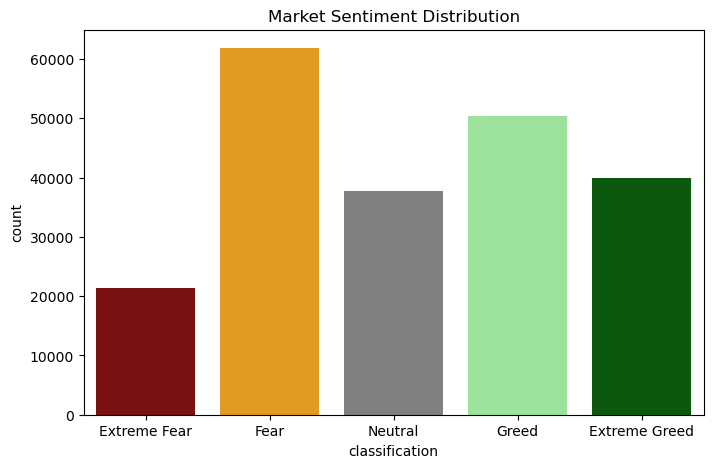

In [20]:
sentiment_order = [
    'Extreme Fear',
    'Fear',
    'Neutral',
    'Greed',
    'Extreme Greed'
]

colors = [
    'darkred',      # Extreme Fear
    'orange',       # Fear
    'gray',         # Neutral
    'lightgreen',   # Greed
    'darkgreen'     # Extreme Greed
]
plt.figure(figsize=(8,5))
sns.countplot(data=merged, x='classification', order=sentiment_order, palette=colors)
plt.title("Market Sentiment Distribution")
plt.show()

In [11]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean()
print(avg_pnl)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [12]:
print(merged['Direction'].unique())

['Buy' 'Sell' 'Open Long' 'Close Long' 'Spot Dust Conversion' 'Open Short'
 'Close Short' 'Long > Short' 'Short > Long' 'Auto-Deleveraging'
 'Liquidated Isolated Short' 'Settlement']


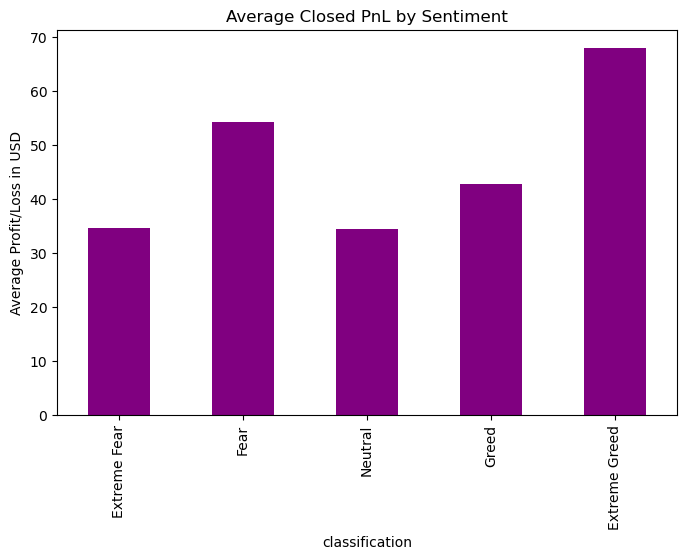

In [46]:
avg_pnl = avg_pnl.reindex(sentiment_order)
plt.figure(figsize=(8,5))
avg_pnl.plot(kind='bar', color='purple')
plt.title("Average Closed PnL by Sentiment")
plt.ylabel("Average Profit/Loss in USD")
plt.show()

In [14]:
volume = merged.groupby('classification')['Size USD'].mean()
print(volume)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


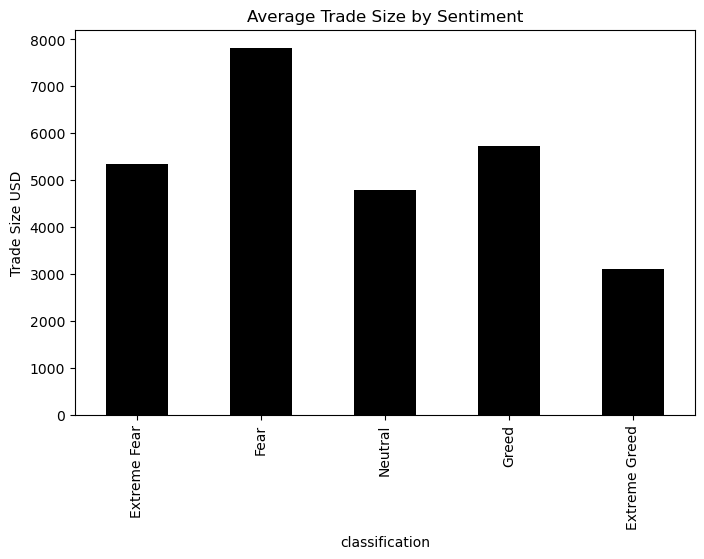

In [47]:
volume = volume.reindex(sentiment_order)
plt.figure(figsize=(8,5))
volume.plot(kind='bar', color = 'black')
plt.title("Average Trade Size by Sentiment")
plt.ylabel("Trade Size USD")
plt.show()

In [16]:
side_analysis = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(side_analysis)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


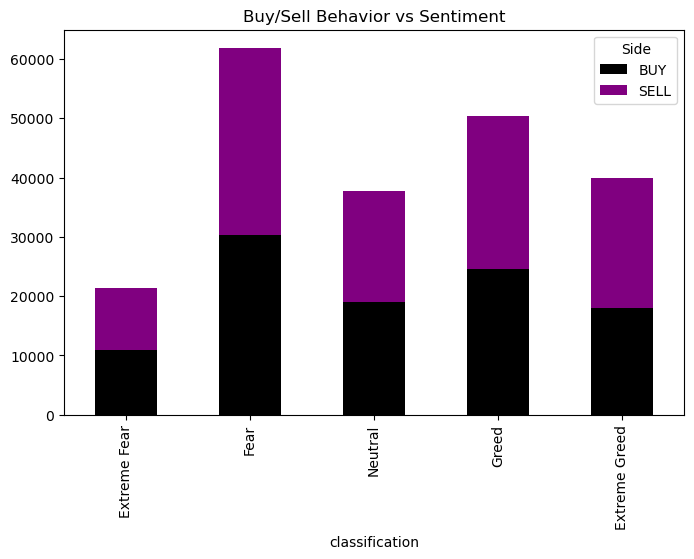

In [49]:
side_analysis = side_analysis.reindex(sentiment_order)
side_analysis.plot(
    kind='bar',
    stacked=True,
    color = ['black', 'purple'],
    figsize=(8,5)
)

plt.title("Buy/Sell Behavior vs Sentiment")

plt.show()

In [39]:
win_rate = merged.groupby(
    'classification'
)['profit_flag'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: profit_flag, dtype: float64


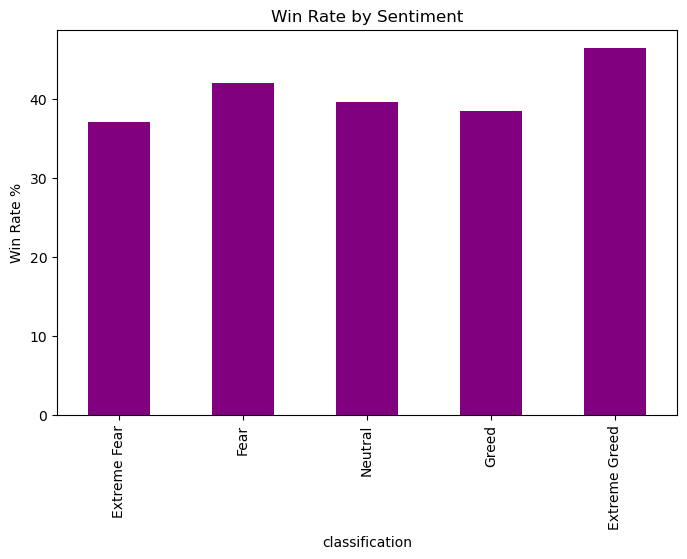

In [50]:
win_rate = win_rate.reindex(sentiment_order)
plt.figure(figsize=(8,5))
win_rate.plot(kind='bar', color = 'purple')
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate %")
plt.show()

In [41]:
top_coins = merged.groupby(
    'Coin'
)['Closed PnL'].sum().sort_values(ascending=False).head(10)

print(top_coins)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


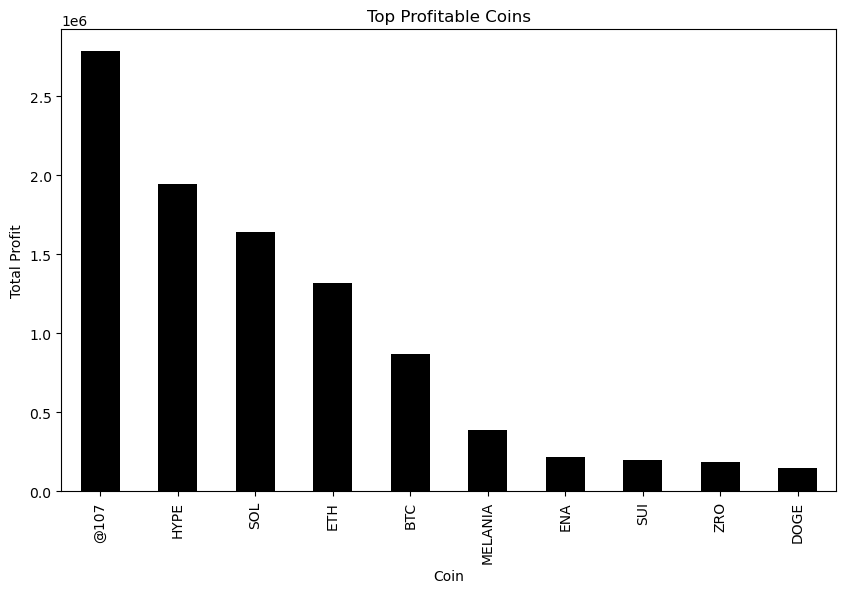

In [42]:
plt.figure(figsize=(10,6))
top_coins.plot(kind='bar', color = 'black')
plt.title("Top Profitable Coins")
plt.ylabel("Total Profit")
plt.show()

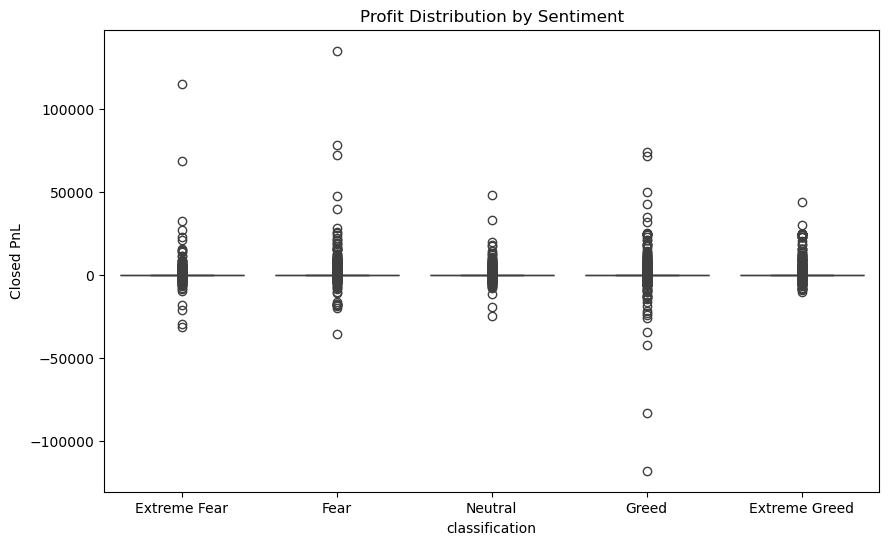

In [52]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL', 
    order = sentiment_order
)

plt.title("Profit Distribution by Sentiment")
plt.show()

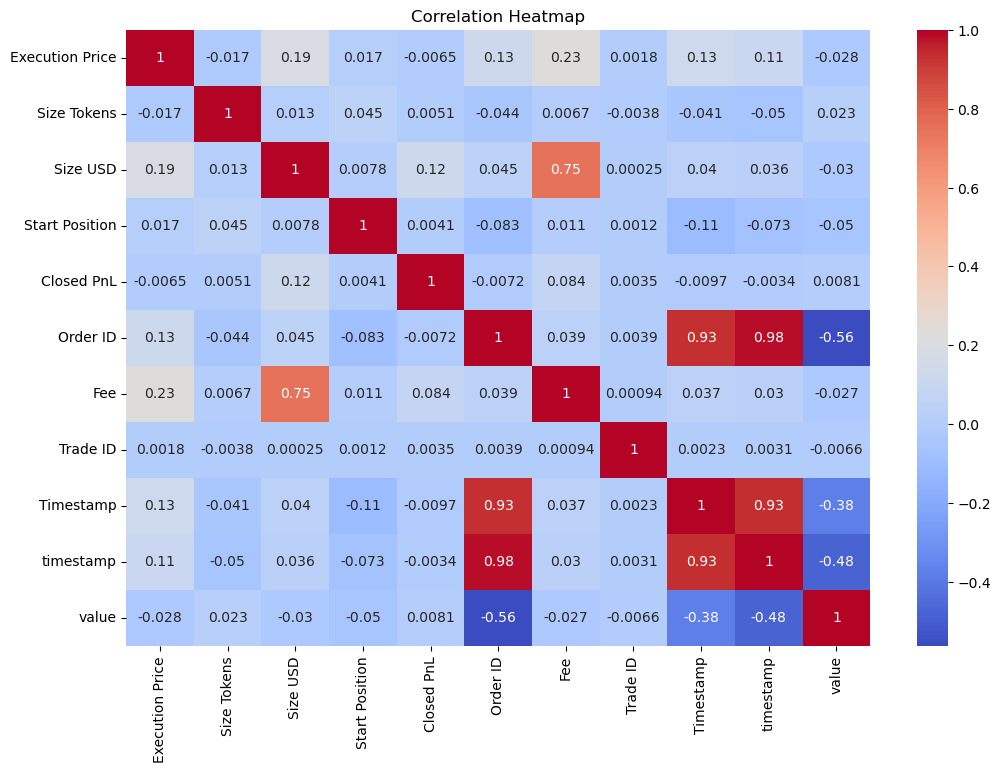

In [44]:
import numpy as np
numeric_cols = merged.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [47]:
merged.to_csv("merged_data.csv", index=False)